<a href="https://colab.research.google.com/github/SukJinJang/Bigdata_computing/blob/main/%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  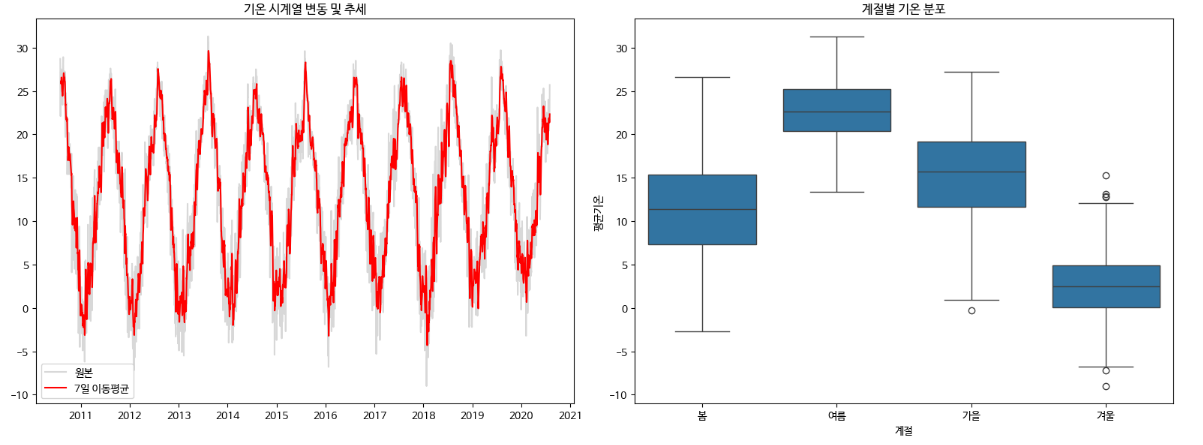

  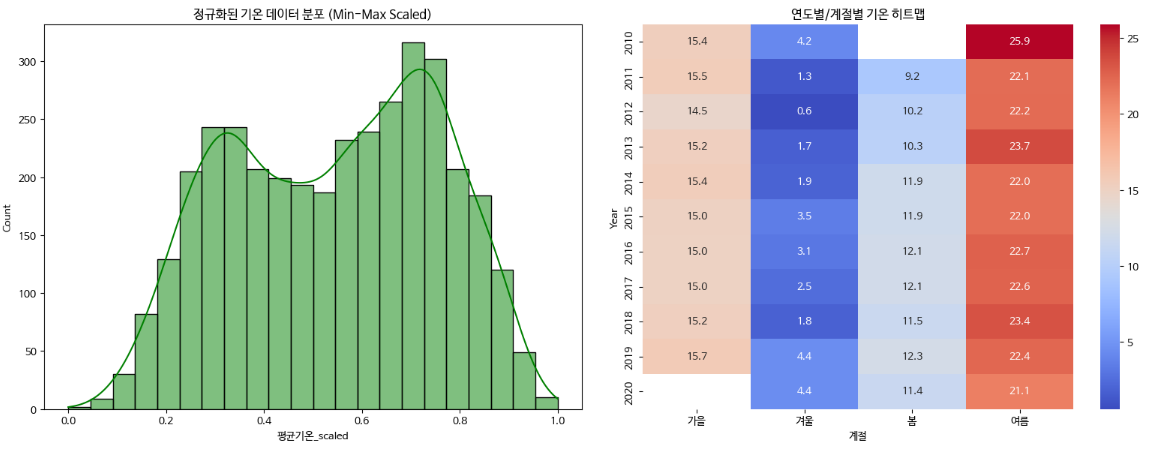



✅ 환경 설정 및 한글 폰트 로드 완료
>> 데이터 수집 완료
>> 시계열 정제 및 피처 생성 완료
>> 데이터 정규화(수동 구현) 및 결합 완료


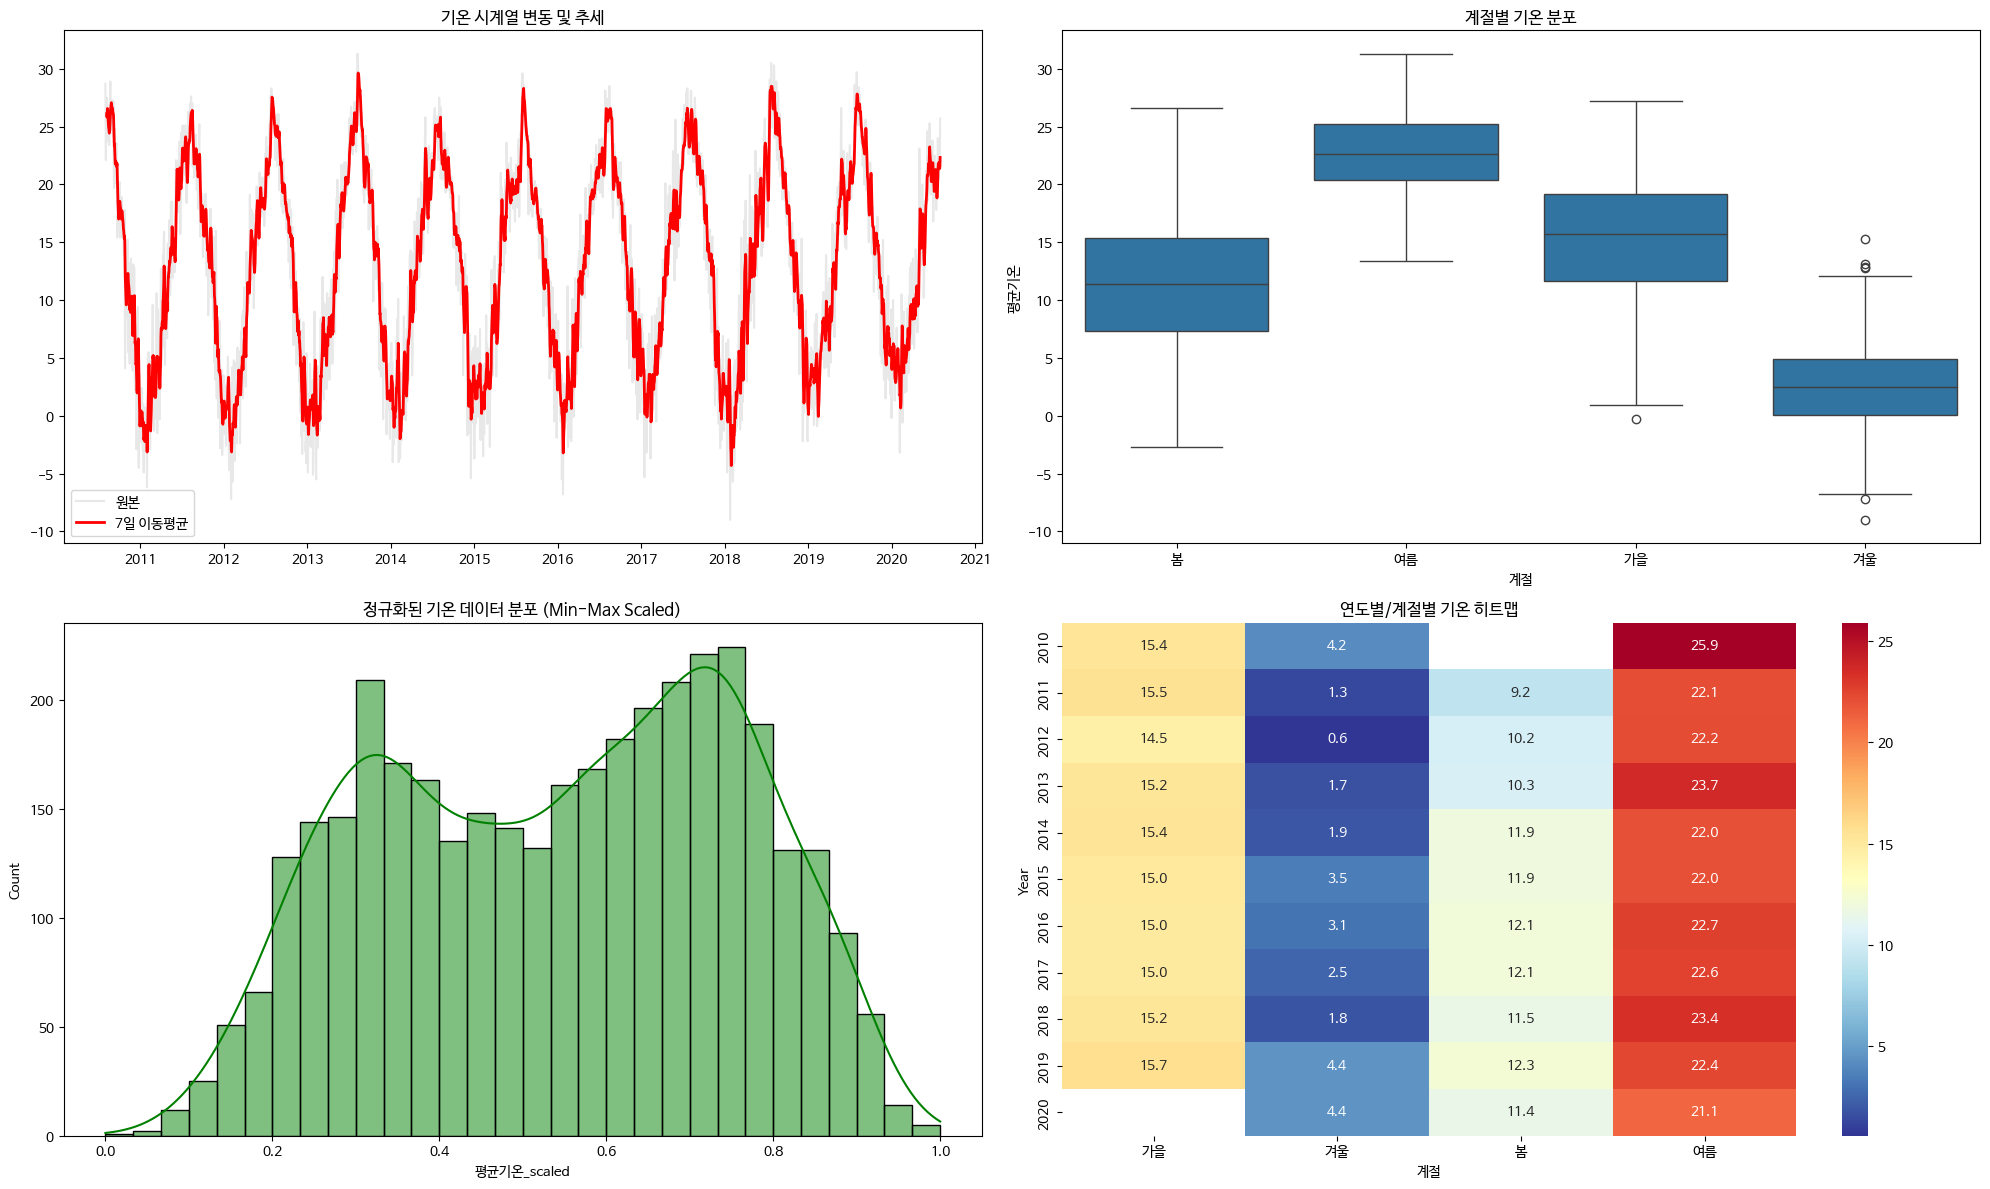

>> 모든 리포트 저장 완료: weather_analysis_report.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.font_manager as fm

# ---------------------------------------------------------
# 1. 환경 설정 및 한글 폰트 로드
# ---------------------------------------------------------
def setup_korean_font():
    """한글 폰트 설정 (수정 버전)"""
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'

    # 1. 폰트 파일 존재 여부 확인 및 설치
    if not os.path.exists(font_path):
        print("Installing Nanum fonts...")
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 폰트 추가
    fm.fontManager.addfont(font_path)

    # 3. 전역 설정 적용
    plt.rc('font', family='NanumBarunGothic')
    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 한글 폰트 설정 완료 (Matplotlib 연동 성공)")

# ---------------------------------------------------------
# 2. 데이터 수집
# ---------------------------------------------------------
def fetch_data(url):
    try:
        df = pd.read_csv(url)
    except UnicodeDecodeError:
        df = pd.read_csv(url, encoding='cp949')
    print(">> 데이터 수집 완료")
    return df

# ---------------------------------------------------------
# 3. 시계열 정제 및 피처 생성
# ---------------------------------------------------------
def preprocess_pipeline(df):
    df['일시'] = pd.to_datetime(df['일시'])
    df.set_index('일시', inplace=True)

    # 결측치 선형 보간 (interpolate)
    df = df.interpolate(method='linear')

    # 7일 이동 평균 (rolling)
    df['7일 이동평균'] = df['평균기온'].rolling(window=7).mean()

    # 계절 정보 추출 (map)
    season_map = {3:'봄', 4:'봄', 5:'봄', 6:'여름', 7:'여름', 8:'여름',
                  9:'가을', 10:'가을', 11:'가을', 12:'겨울', 1:'겨울', 2:'겨울'}
    df['계절'] = df.index.month.map(season_map)
    df['Year'] = df.index.year

    print(">> 시계열 정제 및 피처 생성 완료")
    return df

# ---------------------------------------------------------
# 4. 수치 최적화 및 결합
# ---------------------------------------------------------
def scale_and_merge_data(df):
    """
    학습 내용: Numpy의 min(), max()를 활용한 수동 Scaling 구현
    공식: (데이터 - 최소값) / (최대값 - 최소값)
    """
    target_col = df['평균기온']

    # 1. 최소값과 최대값 계산 (Numpy 리덕션)
    min_val = target_col.min()
    max_val = target_col.max()

    # 2. Min-Max 스케일링 공식 적용
    # 분모가 0이 되는 것을 방지하기 위해 매우 작은 값(1e-7)을 더해주기도 하지만, 여기선 일반적인 상황 가정
    scaled_data = (target_col - min_val) / (max_val - min_val)

    # 3. 데이터 프레임 결합 (pd.concat)
    # Series 형태이므로 바로 이름을 지정하여 concat 가능
    df = pd.concat([df, scaled_data.rename('평균기온_scaled')], axis=1)

    print(">> 데이터 정규화(수동 구현) 및 결합 완료")
    return df

# ---------------------------------------------------------
# 5. 데이터 재구조화 및 통계
# ---------------------------------------------------------
def restructure_analysis(df):
    seasonal_stats = df.groupby('계절')['평균기온'].describe()

    pivot_res = df.pivot_table(index='Year', columns='계절', values='평균기온', aggfunc='mean')
    # 열 순서 고정 (지시서 이미지 준수)
    pivot_res = pivot_res[['가을', '겨울', '봄', '여름']]

    return seasonal_stats, pivot_res

# ---------------------------------------------------------
# 6. 시각화
# ---------------------------------------------------------
def visualize_results(df, pivot_res):
    plt.figure(figsize=(20, 12))

    # (1) 시계열 추세
    plt.subplot(2, 2, 1)
    plt.plot(df.index, df['평균기온'], color='lightgray', alpha=0.5, label='원본')
    plt.plot(df.index, df['7일 이동평균'], color='red', linewidth=2, label='7일 이동평균')
    plt.title('기온 시계열 변동 및 추세')
    plt.legend()

    # (2) 계절별 분포
    plt.subplot(2, 2, 2)
    sns.boxplot(data=df, x='계절', y='평균기온', order=['봄', '여름', '가을', '겨울'])
    plt.title('계절별 기온 분포')

    # (3) 정규화 분포 (Histplot)
    plt.subplot(2, 2, 3)
    sns.histplot(df['평균기온_scaled'], kde=True, color='green', bins=30)
    plt.title('정규화된 기온 데이터 분포 (Min-Max Scaled)')

    # (4) 히트맵
    plt.subplot(2, 2, 4)
    sns.heatmap(pivot_res, annot=True, fmt=".1f", cmap='RdYlBu_r')
    plt.title('연도별/계절별 기온 히트맵')

    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 7. 데이터 저장
# ---------------------------------------------------------
def save_final_reports(df_list, names, file_name):
    # CSV 저장
    df_list[0].to_csv('cleaned_weather_data.csv', encoding='utf-8-sig')

    # 다중 시트 엑셀 저장
    with pd.ExcelWriter(file_name) as writer:
        for data, s_name in zip(df_list, names):
            data.to_excel(writer, sheet_name=s_name)

    print(f">> 모든 리포트 저장 완료: {file_name}")

# ---------------------------------------------------------
# 실행 제어
# ---------------------------------------------------------
if __name__ == "__main__":
    setup_environment()

    URL = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"
    raw_data = fetch_data(URL)

    # 파이프라인 가동
    processed_data = preprocess_pipeline(raw_data)
    final_data = scale_and_merge_data(processed_data)

    stats, pivot = restructure_analysis(final_data)

    visualize_results(final_data, pivot)

    save_final_reports(
        [final_data, stats, pivot],
        ['전처리데이터', '계절별통계', '연도별피벗'],
        'weather_analysis_report.xlsx'
    )